In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import datetime as dt
%matplotlib inline
import os
import sys
from tqdm import tqdm
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
# from opendrift.readers import reader_netCDF_CF_generic
# from opendrift.readers import reader_global_landmask
# import opendrift.readers as readers
# from opendrift.models.oceandrift import OceanDrift
from datetime import timedelta
from scipy.interpolate import griddata

In [6]:
hfr_files, hfr_filepaths = tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/HFR/','nc_files',file_end='nc')
hfr = xr.open_mfdataset(hfr_filepaths).chunk(dict(time=-1))

In [49]:
hfr = hfr.where(hfr['hdop']<1.25)
hfr = hfr.sel(time='2012-08')

In [50]:
hfr_u = hfr['u'].interpolate_na(dim='time',method='linear',limit=2).interpolate_na(dim='lon',method='linear',limit=2).interpolate_na(dim='lat',method='linear',limit=2)
hfr_v = hfr['v'].interpolate_na(dim='time',method='linear',limit=2).interpolate_na(dim='lat',method='linear',limit=2).interpolate_na(dim='lon',method='linear',limit=2)


In [51]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'

model_uv = xr.open_dataset(path_tohd + 'cutouts/uv_cape_mend_llc4320.nc').isel(k=0)
lcs_model = xr.open_dataset('/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

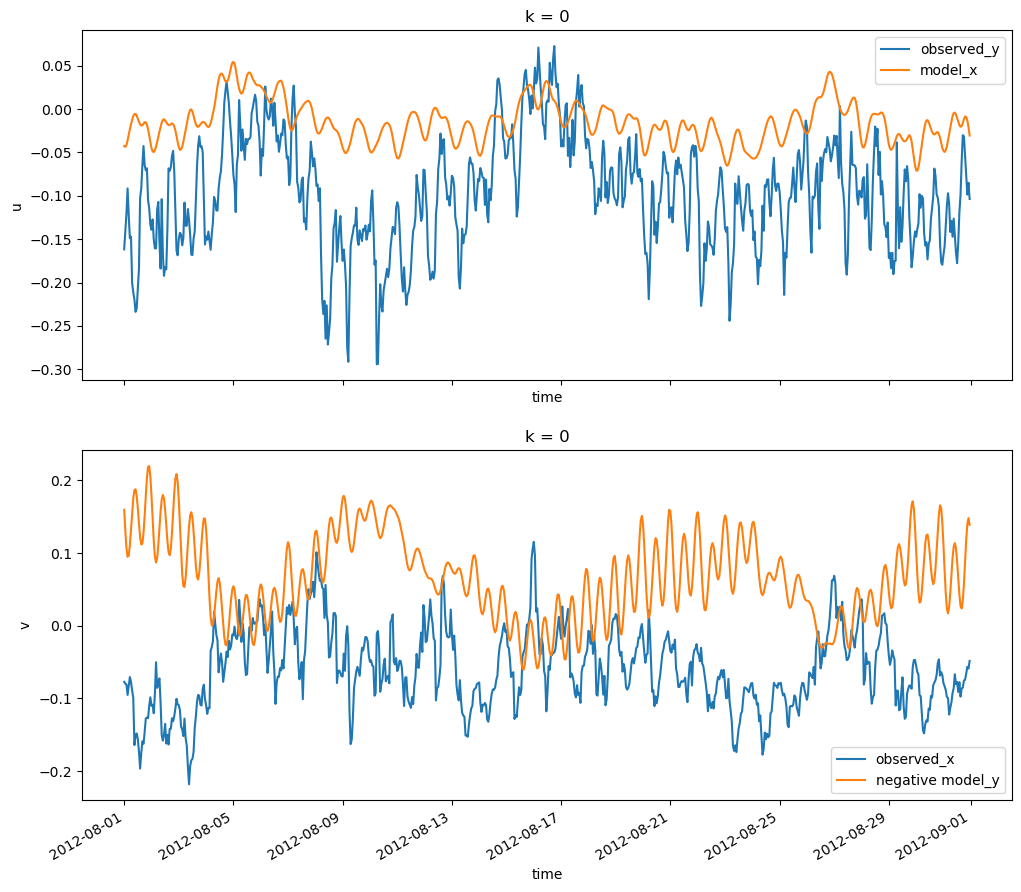

In [52]:
fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(12,10),sharex=True)
hfr['v'].mean(dim='lat',skipna=True).mean(dim='lon',skipna=True).plot(ax=ax[0],label='observed_y')
(model_uv.sel(time='2012-08',j=slice(325,426))['u']).mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(ax=ax[0],label='model_x')
hfr['u'].mean(dim='lat',skipna=True).mean(dim='lon',skipna=True).plot(ax=ax[1],label='observed_x')
(model_uv.sel(time='2012-08',j=slice(325,426))['v']*-1).mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(ax=ax[1],label='negative model_y')
ax[0].legend()
ax[1].legend()

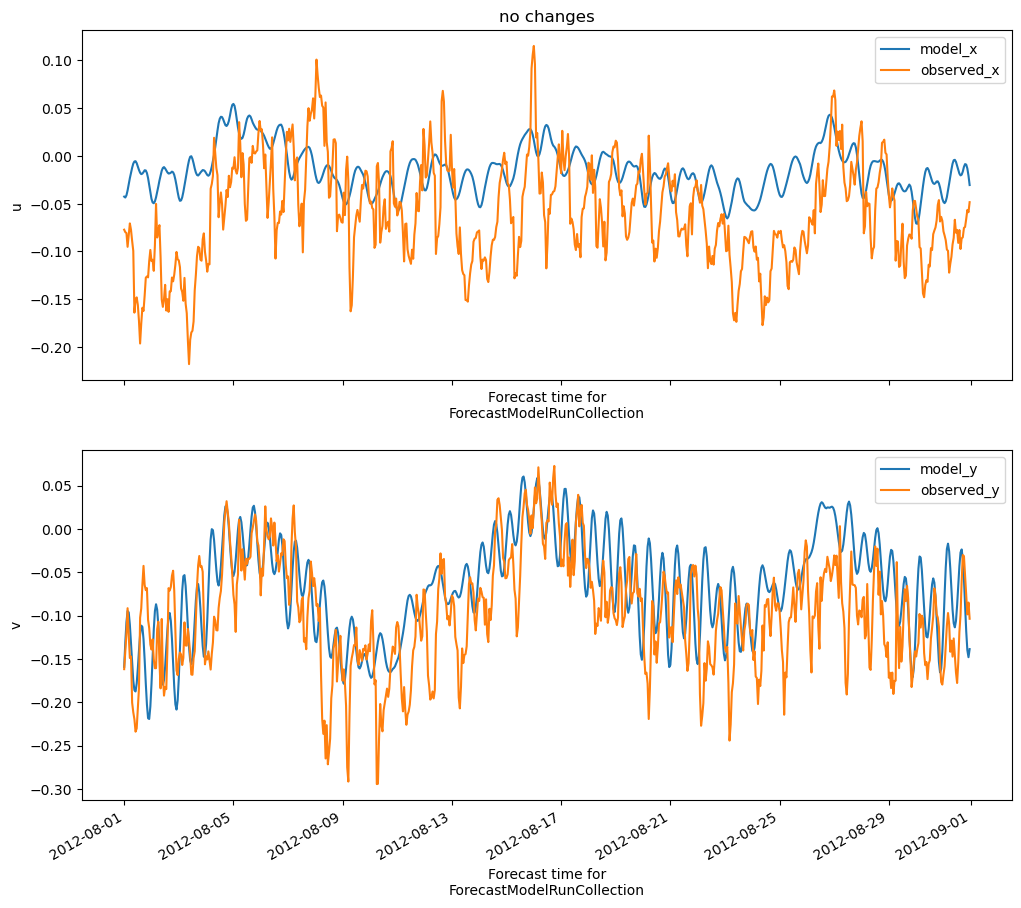

In [53]:
fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(12,10),sharex=True)
(model_uv.sel(time='2012-08',j=slice(325,426))['u']).mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(ax=ax[0],label='model_x')
hfr['u'].mean(dim='lat',skipna=True).mean(dim='lon',skipna=True).plot(ax=ax[0],label='observed_x')
(model_uv.sel(time='2012-08',j=slice(325,426))['v']).mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(ax=ax[1],label='model_y')
hfr['v'].mean(dim='lat',skipna=True).mean(dim='lon',skipna=True).plot(ax=ax[1],label='observed_y')
ax[0].set_title('no changes')
ax[0].legend()
ax[1].legend()

In [54]:
hfr.time

<xarray.DataArray 'time' (time: 744)>
array(['2012-08-01T00:00:00.000000000', '2012-08-01T01:00:00.000000000',
       '2012-08-01T02:00:00.000000000', ..., '2012-08-31T21:00:00.000000000',
       '2012-08-31T22:00:00.000000000', '2012-08-31T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time      (time) datetime64[ns] 2012-08-01 ... 2012-08-31T23:00:00
    time_run  (time) datetime64[ns] dask.array<chunksize=(744,), meta=np.ndarray>
Attributes:
    long_name:            Forecast time for ForecastModelRunCollection
    standard_name:        time
    _CoordinateAxisType:  Time

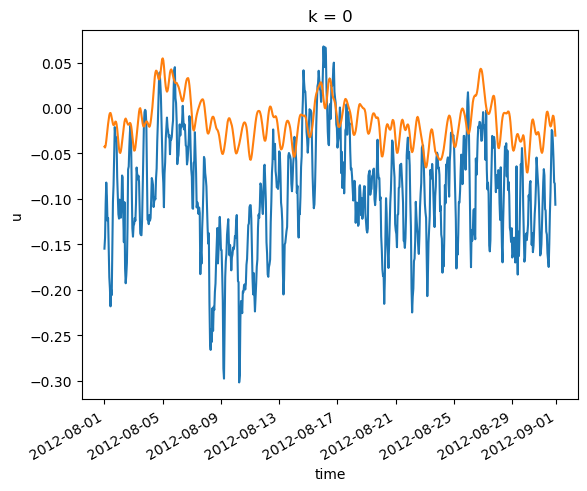

In [35]:
hfr['v'].mean(dim='lat',skipna=True).mean(dim='lon',skipna=True).plot()
(model_uv.sel(time='2012-08',j=slice(325,426))['u']).mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot()

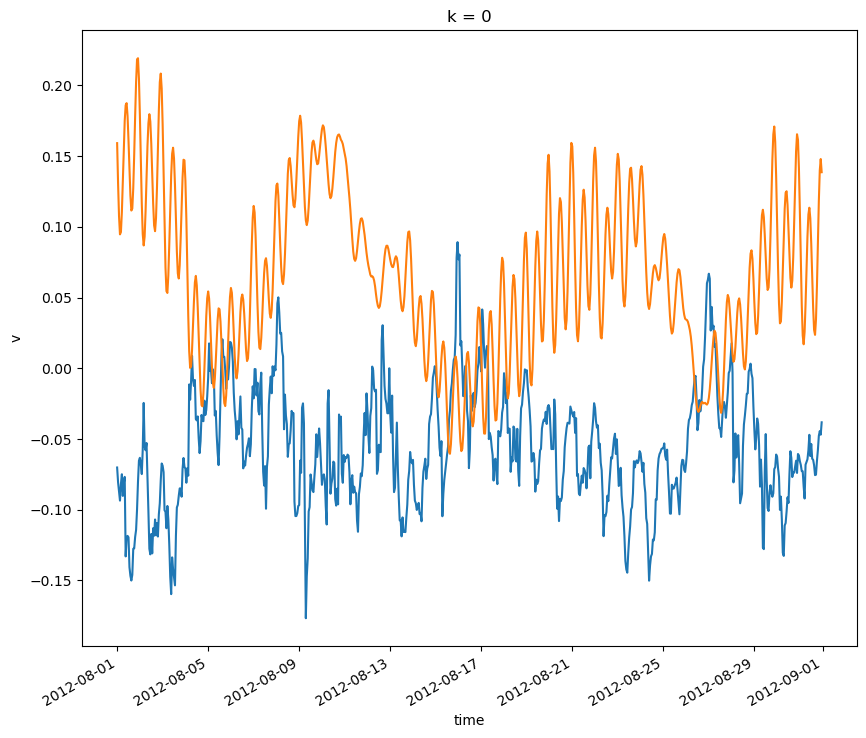

In [34]:
hfr['u'].mean(dim='lat',skipna=True).mean(dim='lon',skipna=True).plot(figsize=(10,8))
(model_uv.sel(time='2012-08',j=slice(325,426))['v']*-1).mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot()

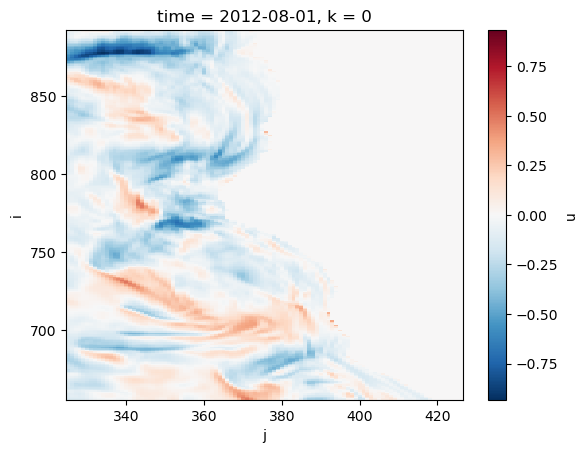

In [20]:
model_uv.sel(time='2012-08',j=slice(325,426))['u'].mean(dim='lat',skipna=True).mean(dim='lon',skipna=True).plot()

In [43]:
hfr_for_opendrift = xr.merge([hfr_u,hfr_v]).dropna(dim='time',how='all')

In [44]:
hfr

<xarray.Dataset>
Dimensions:                (time: 744, time_1: 1, nv: 2, lat: 74, lon: 234)
Coordinates:
  * lat                    (lat) float32 38.02 38.07 38.13 ... 41.85 41.9 41.95
  * lon                    (lon) float32 -130.4 -130.3 -130.2 ... -115.9 -115.8
  * time                   (time) datetime64[ns] 2012-08-01 ... 2012-08-31T23...
    time_run               (time) datetime64[ns] dask.array<chunksize=(744,), meta=np.ndarray>
Dimensions without coordinates: time_1, nv
Data variables: (12/14)
    time_bnds              (time, time_1, nv, lat, lon) float64 dask.array<chunksize=(744, 1, 2, 74, 234), meta=np.ndarray>
    depth_bnds             (time, nv, lat, lon) float32 dask.array<chunksize=(744, 2, 74, 234), meta=np.ndarray>
    wgs84                  (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    processing_parameters  (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    radial_metadata        (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    depth                  (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    ...                     ...
    v                      (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    dopx                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    dopy                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    hdop                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    number_of_sites        (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    number_of_radials      (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
Attributes: (12/31)
    Conventions:               CF-1.4, ACDD-1.3
    id:                        202311121400siohfruwlsrtvuswc6km
    date_created:              2023-11-12T16:23:28Z
    source:                    surface ocean velocity field from hf-radar
    program:                   Integrated Ocean Observing System (IOOS)
    title:                     Near-Real Time Surface Ocean Velocity, U.S. We...
    ...                        ...
    format_version:            1.1.00
    product_version:           2.0.00
    _CoordSysBuilder:          ucar.nc2.dataset.conv.CF1Convention
    cdm_data_type:             GRID
    featureType:               GRID
    location:                  Proto fmrc:HFRADAR_US_West_Coast_6km_Resolutio...

In [3]:
path_tohd = '/media/basil/Elements/data/Thesis/LLC4320/nc_files/'

model_uv = xr.open_dataset(path_tohd + 'cutouts/uv_cape_mend_llc4320.nc').isel(k=0)
lcs_model = xr.open_dataset('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

In [4]:
u_model = model_uv.sel(time='2012-01-01').isel(time=4)['u'].where(model_uv.lon>-126)
v_model = model_uv.sel(time='2012-01-01').isel(time=4)['v'].where(model_uv.lon>-126)

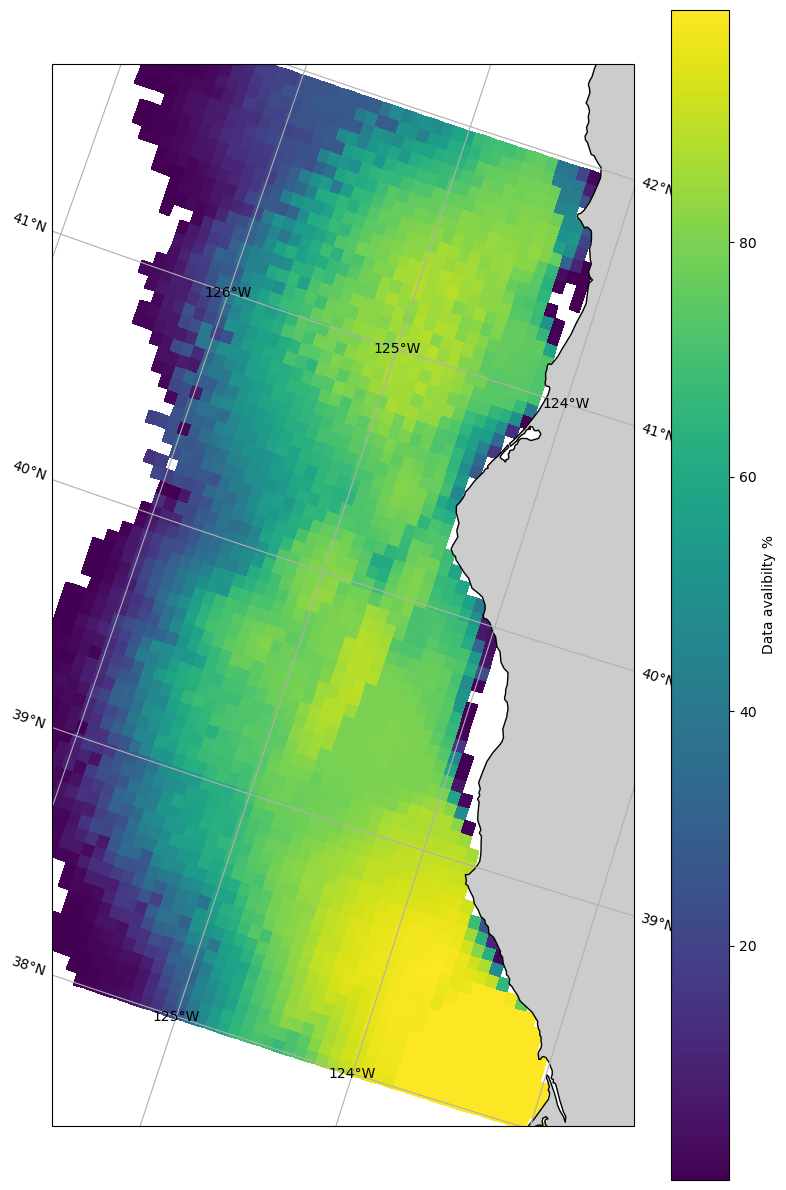

In [11]:
finite_values = np.isfinite(hfr['u'])
spatial_var = finite_values.sum(dim={'time'})/len(finite_values.time)

spatial_var = spatial_var.where(spatial_var != 0)
masks_greater90 = spatial_var.where(((spatial_var>.85)))
tools.map_capemend(spatial_var*100, labelz = 'Data avalibilty %',figsize=(8,12))
plt.savefig('./Data_avalibility.png')
#(spatial_var*100).plot(alpha=.75,cbar_kwargs={'label':'Data avalibilty %'})
# plt.xlim(-127,-123)
# plt.ylim(38,42)

In [45]:
o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o.set_config('general:coastline_action', 'previous') 
o.set_config('drift:advection_scheme', 'runge-kutta4')
o.set_config('general:time_step_minutes', 60)
o.set_config('drift:stokes_drift', False)
#o.set_config('seed:ocean_only', True)
o.set_config('general:use_auto_landmask', False)
#o.set_config('environment:fallback:land_binary_mask', 1)
o_diffusion.set_config('general:coastline_action', 'stranding') 
o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
o_diffusion.set_config('general:time_step_minutes', 60)
o_diffusion.set_config('drift:stokes_drift', False)
o_diffusion.set_config('drift:current_uncertainty_uniform', 0)
o_diffusion.set_config('general:use_auto_landmask', False)
reader_data = reader_netCDF_CF_generic.Reader(hfr_for_opendrift)
reader_landmask = reader_global_landmask.Reader()
#reader_landmask.activate_environment_mapping('land_binary_mask_from_ocean_depth')
#reader_data.activate_environment_mapping('land_binary_mask_from_ocean_depth')
o.add_reader([reader_data,reader_landmask])
o_diffusion.add_reader([reader_data,reader_landmask])

In [46]:
reader_data

Reader: <xarray.Dataset>
Dimensions:   (lat: 74, lon: 234, time: 744)
Coordinates:
  * lat       (lat) float32 38.02 38.07 38.13 38.18 ... 41.79 41.85 41.9 41.95
  * lon       (lon) float32 -130.4 -130.3 -130.2 -130.2 ... -115.9 -115.9 -115.8
  * time      (time) datetime64[ns] 2012-08-01 ... 2012-08-31T23:00:00
    time_run  (time) datetime64[ns] dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    u         (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    v         (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
Attributes:
    units:                m s-1
    long_name:            surface_eastward_sea_water_velocity
    standard_name:        surface_eastward_sea_water_velocity
    grid_mapping:         wgs84
    cell_methods:         depth: mean time: mean
    ancillary_variables:  dopx
    _ChunkSizes:          [  1 367 234]
Projection: 
  +proj=latlong
Coverage: [degrees]
  xmin: -130.360001   xmax: -115.

In [47]:
lcs = o.calculate_ftle( 
    time=reader_data.start_time + timedelta(hours=0),
    time_step=timedelta(minutes=60),
    duration=timedelta(hours=6), delta_x=0.06246948,delta_y=.05393982,reader=reader_data,
    RLCS=True)

13:10:22 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:22 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:10:35 WARNING opendrift:133: Still NaN-values aft

In [48]:
lcs_lat = lcs['lat']
lcs_lon = lcs['lon']
alcs_time = lcs['time']
alcs_data = lcs['ALCS'].data
time = alcs_time
lat = lcs_lat[:,0]
lon = lcs_lon[0,:]
rlcs_data = lcs['RLCS'].data

ALCS = xr.DataArray(alcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='ALCS')
RLCS = xr.DataArray(rlcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='RLCS')

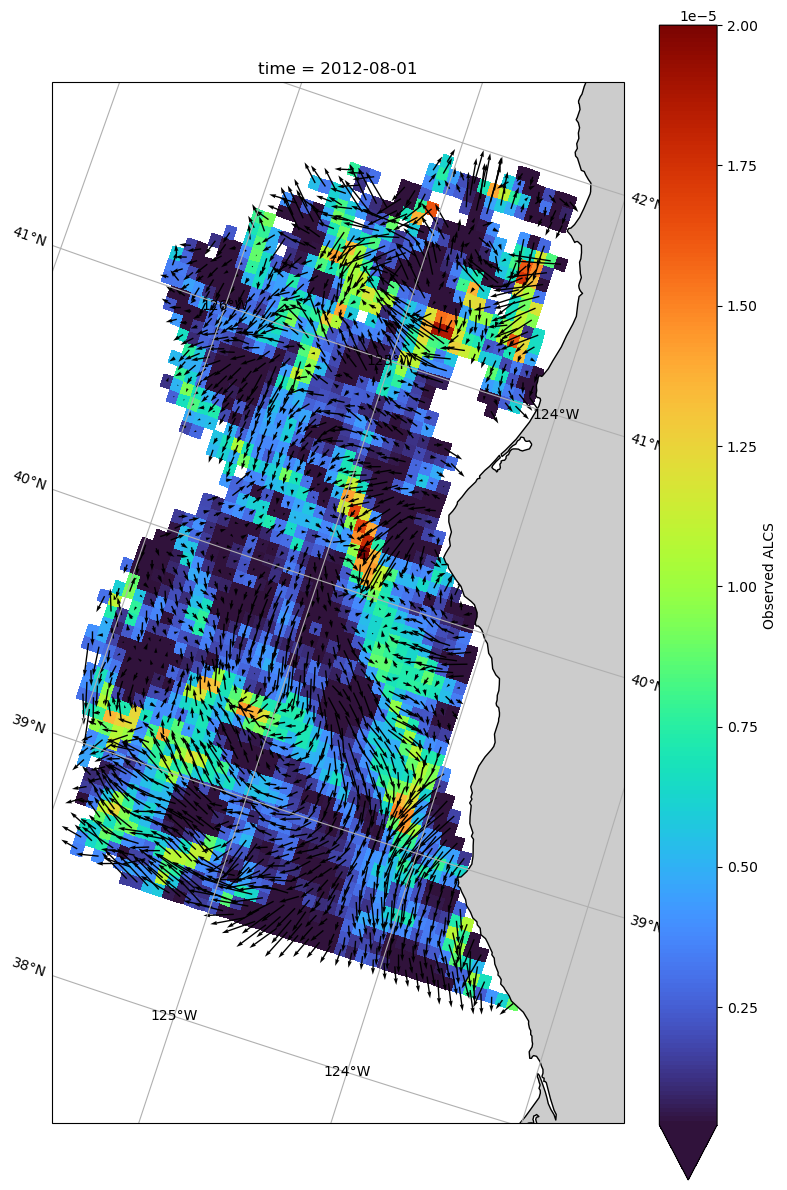

In [51]:
#hfr.isel(time=0)['u'].plot()

FTLE_threshold = [4e-7,2e-5] #Attracting

[1e-5,1e-4]
tools.map_capemend(hfr.sel(lat=slice(38.5,42)).isel(time=0)['u'],hfr.sel(lat=slice(38.5,42)).isel(time=0)['v'],ALCS.isel(time=0).where(np.array(np.isfinite(hfr['u'].isel(time=0)[:,:-1]))).sel(lat=slice(38.5,42)), scl=10,zmin = FTLE_threshold[0],zmax=FTLE_threshold[1],colorstyle='turbo',labelz = 'Observed ALCS',figsize=(8,12))
plt.tight_layout()
plt.savefig('./Observed_lcs.png')
#tools.map_capemend(u_model[::4,::4],v_model[::4,::4],lcs_model['ALCS'].sel(lon=slice(-126,-123),time='2012-01-01').isel(time=0), scl=10,zmin = FTLE_threshold[0],zmax=FTLE_threshold[1],colorstyle='turbo',labelz = 'Model ALCS', figsize=(8,12))
#plt.tight_layout()

plt.savefig('./Model_lcs.png')


In [52]:
for i in tqdm(range(0,int(len(hfr.time)/6))):
    lcs = o.calculate_ftle( 
        time=reader_data.start_time + timedelta(hours=0+i*6),
        time_step=timedelta(minutes=60),
        duration=timedelta(hours=6), delta_x=0.06246948,delta_y=0.05393982,reader=reader_data,
        RLCS=True)
    lcs_lat = lcs['lat']
    lcs_lon = lcs['lon']
    alcs_time = lcs['time']
    alcs_data = lcs['ALCS'].data
    time = alcs_time
    lat = lcs_lat[:,0]
    lon = lcs_lon[0,:]
    rlcs_data = lcs['RLCS'].data

    ALCS = xr.DataArray(alcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='ALCS_hfr')
    RLCS = xr.DataArray(rlcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='RLCS_hfr')
    LCS = xr.merge([ALCS,RLCS])
    LCS.to_netcdf('/media/basil/Elements/data/Thesis/HFR/FTLE_fields/lcs_hfr_'+str(i).zfill(4)+'.nc')

  0%|                                                   | 0/124 [00:00<?, ?it/s]13:16:30 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:30 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
13:16:43 WARNING opendrift:133: Still NaN-values af

In [ ]:
# to do counts, need to normalize to avalible points -> take np.isfinite(n hr)*...*np.isfinite(n+6 hr) = avalible points -> 
# avalible points(6hr) * FTLE_field(6hr)